# Tutorial: Milestone 4 - Cross-Modal Dialogue

Audience:
- You've completed Milestone 3 (MISA fusion: shared/private modality representations,
  self-attention over 6 fixed vectors, one utterance classified in isolation).

Prerequisites:
- Run `python src/generate_dialogue_data.py`, `python src/extract_dialogue_embeddings.py`,
  `python src/crossmodal_model.py` (a quick smoke test), and `python src/train_crossmodal.py`
  at least once first -- this notebook imports the model class from `src/crossmodal_model.py`
  rather than redefining it, exactly like Milestone 3's notebook imported `src/misa_model.py`.

Learning goals:
- By the end, you can explain the difference between cross-attention and self-attention,
  what a padding mask is and why this milestone needs one, and why splitting the data by
  EPISODE (not by row) matters here in a way it didn't for any earlier milestone.

**What's new here:** every milestone through M3 classified one utterance in isolation, with
no notion of "what was said before it." This milestone is the first to use dialogue context
(up to 4 preceding utterances) and the first to let one modality's sequence directly attend
into another modality's sequence (cross-attention), rather than attending within a fixed set
of per-utterance representations (M3's self-attention).


## Outline

1. Setup
2. Step 1 - Load the dialogue index (512 rows, 10 episodes)
3. Step 2 - Split by EPISODE, not by row (context leakage)
4. Step 3 - The cross-modal architecture, in plain language
5. Step 4 - Build the dialogue-window tensors (and the padding mask)
6. Step 5 - Train the full model AND the no-cross-attention ablation
7. Training curves (full vs. ablation, side by side)
8. Step 6 - Evaluate both models on the held-out test episodes
9. Confusion matrix
10. Compare against every prior milestone
11. Look at the mistakes
12. Exercises
13. Pitfalls and extensions


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
sys.path.insert(0, str(PROJECT_ROOT / "src"))
from crossmodal_model import CrossModalDialogueModel, WINDOW_SIZE  # the reviewed model class -- not redefined here

INDEX_PATH = PROJECT_ROOT / "data" / "dialogue" / "index.csv"
EMBEDDINGS_DIR = PROJECT_ROOT / "data" / "dialogue" / "embeddings"

AUDIO_SEQ_LEN = 8
N_FRAMES = 5
print(f"WINDOW_SIZE (context + target) = {WINDOW_SIZE}")
INDEX_PATH


WINDOW_SIZE (context + target) = 5


WindowsPath('C:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/dialogue/index.csv')

## Step 1 - Load the dialogue index

Unlike M2/M3's 300-clip *stratified* sample (15 clips per intent class, scattered across 43
episodes -- good for balanced classes, useless for "what came before this utterance"), this
milestone uses 10 **complete, contiguous** episodes (~512 clips) so that dialogue context is
real, temporally-ordered dialogue, not an arbitrary bag of clips.

Each row already has its up-to-4-preceding-utterance context precomputed as
`context_sample_ids` (semicolon-joined, oldest first, empty for an episode's very first
utterance).


In [2]:
df = pd.read_csv(INDEX_PATH)
df["context_sample_ids"] = df["context_sample_ids"].fillna("")
n_episodes = df.groupby(["season", "episode"]).ngroups
print(f"Loaded {len(df)} rows across {n_episodes} episodes")
df[["sample_id", "target_text", "target_intent", "season", "episode", "context_sample_ids"]].head()


Loaded 512 rows across 10 episodes


,sample_id,target_text,target_intent,season,episode,context_sample_ids
0,S04_E01_29,thanks for the company.,Thank,S04,E01,
1,S04_E01_31,thank you for always tipping 20 bucks,Thank,S04,E01,S04_E01_29
2,S04_E01_42,or you guys can just use your phones for all t...,Inform,S04,E01,S04_E01_29;S04_E01_31
3,S04_E01_77,"these are all excellent ideas, thank you.",Praise,S04,E01,S04_E01_29;S04_E01_31;S04_E01_42
4,S04_E01_87,"thanks for checking in, though!",Thank,S04,E01,S04_E01_29;S04_E01_31;S04_E01_42;S04_E01_77


## Step 2 - Split by EPISODE, not by row

**This is worth its own section, because it's a real and easy-to-get-wrong methodological
point.** Every single prior milestone in this project (M0 through M3) split its data with
`sklearn.model_selection.train_test_split` at the *row* level: shuffle every example, carve
off some percentage for train/val/test. That was fine when every row was independent -- one
utterance, classified with no reference to any other row.

That assumption breaks here. Each row's features now include up to 4 *other* rows' audio,
video, and text (its dialogue context). If a plain row-level split were used, it would be
entirely possible for utterance 50's context (utterances 46-49) to land in the **training**
split while utterance 50 itself landed in the **test** split. The model would then effectively
be evaluated on a test example that it partially saw during training -- test performance would
look better than the model actually deserves, without the model having learned anything more
general. This is called **context leakage** (a special case of the more general "data
leakage"), and it is a genuine bug, not a theoretical concern: the whole point of a held-out
test set is that nothing about it, directly or indirectly, was visible during training.

The fix: split at the **episode** level instead. All 512 rows from a given episode go
entirely into train, entirely into val, or entirely into test -- never split across two of
them. Since every row's context always comes from its own episode (context never crosses
episode boundaries -- an episode's first few utterances just have less context, see Step 4),
an episode-level split guarantees no context lookup can ever cross a split boundary.

7 episodes go to train, 1 to val, 2 to test (seeded, not stratified -- stratifying only 10
groups by which of 20 classes they contain isn't practically meaningful with groups this
small; a plain seeded selection is used and stated as such, not dressed up as more rigorous
than it is).


In [3]:
# Episodes assigned to each split -- by EPISODE, not by utterance, so a
# target utterance's context never crosses into a different split than the
# target itself. Same assignment as src/train_crossmodal.py.
TRAIN_EPISODES = [
    ("S04", "E16"), ("S04", "E04"), ("S04", "E01"), ("S05", "E19"),
    ("S05", "E18"), ("S06", "E03"), ("S06", "E04"),
]
VAL_EPISODES = [("S06", "E02")]
TEST_EPISODES = [("S05", "E20"), ("S06", "E01")]


def episode_in(row, episode_set):
    return (row["season"], row["episode"]) in episode_set


train = df[df.apply(lambda r: episode_in(r, TRAIN_EPISODES), axis=1)].reset_index(drop=True)
val = df[df.apply(lambda r: episode_in(r, VAL_EPISODES), axis=1)].reset_index(drop=True)
test = df[df.apply(lambda r: episode_in(r, TEST_EPISODES), axis=1)].reset_index(drop=True)

print(f"train: {len(train)} samples across {len(TRAIN_EPISODES)} episodes")
print(f"val:   {len(val)} samples across {len(VAL_EPISODES)} episode")
print(f"test:  {len(test)} samples across {len(TEST_EPISODES)} episodes")


train: 365 samples across 7 episodes
val:   40 samples across 1 episode
test:  107 samples across 2 episodes


## Step 3 - The cross-modal architecture, in plain language

**Cross-attention vs. self-attention.** M3's MISA took a single utterance, encoded it into 6
fixed vectors (3 "shared" + 3 "private", one per modality), and ran **self-attention** over
those 6 vectors -- each of the 6 could look at the other 5 and itself, refining its own
representation. Every input to that attention step was a representation of the *same*
utterance.

This milestone does something different: **cross-attention**, where one modality's sequence
directly attends *into* another modality's sequence. Concretely -- M3 let 6 fixed
representations attend to each other; M4 lets one modality's sequence (audio's 8 timesteps,
video's 5 frames) directly attend into another modality's sequence (text), rather than
attending within a fixed set of per-utterance representations. Audio and video aren't
squashed into single vectors first and then mixed in with text symmetrically -- instead, text
acts as a **query** ("what should I look for"), and audio/video act as **key/value** pairs
("what's available to match against" / "what do I actually retrieve"). The result is a text
representation that has been *enriched* by whichever audio timesteps and video frames were
most relevant to it, rather than an unweighted average of all of them.

**Dialogue context.** On top of that, this milestone gives the model up to 4 utterances of
context before the target. Each of the 5 window positions (4 context + 1 target) goes through
the same audio-to-text / video-to-text cross-attention step, producing one enriched vector per
utterance. Those 5 vectors are then stacked into a short sequence and run through one more
**self-attention** layer (`dialogue_self_attn` below) -- so the target utterance's final
representation can be influenced by the context utterances around it -- before the last
(target) position is classified. So this milestone actually uses *both* mechanisms: cross-
attention (audio/video into text, per utterance) and self-attention (across the 5-position
dialogue window) -- just not self-attention over a fixed per-modality decomposition the way M3
did.

**What is a padding mask, and why does this milestone need one?** Not every utterance has a
full 4-utterance history -- an episode's first utterance has zero real predecessors, its
second utterance has one, and so on. Rather than dropping those rows (losing training data) or
pretending they have context they don't, `build_window_tensors` (Step 4) fills the missing
context positions with zeros and marks them in a **padding mask**: a `(batch, WINDOW_SIZE)`
boolean array where `True` means "this position is a placeholder, not real data." The
dialogue-window self-attention layer is told to ignore `True` positions entirely, so an
episode's early utterances aren't penalized for having a shorter history -- the model attends
only over whatever real context actually exists.


In [4]:
# Peek at the model's structure and size (text_dim is a placeholder just to inspect shape).
model_preview = CrossModalDialogueModel(text_dim=1400, hidden_dim=128, num_classes=20)
n_params = sum(p.numel() for p in model_preview.parameters())
print(model_preview)
print(f"\nTotal trainable parameters: {n_params:,}")


CrossModalDialogueModel(
  (text_proj): Linear(in_features=1400, out_features=128, bias=True)
  (audio_proj): Linear(in_features=768, out_features=128, bias=True)
  (video_proj): Linear(in_features=512, out_features=128, bias=True)
  (audio_to_text_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (video_to_text_attn): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
  )
  (dialogue_self_attn): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,),

## Step 4 - Build the dialogue-window tensors

For every row, build a `(WINDOW_SIZE, ...)` tensor of text/audio/video features -- one slot
per window position -- plus the padding mask described above. Context positions are
**left-padded**: the earliest real context goes as far left as fits, and the last position
(`WINDOW_SIZE - 1`) is always the target utterance, never padding. Context utterances always
come from the same episode as their target (and episodes are entirely within one split), so
every context lookup resolves inside the same dataframe -- no cross-split lookup is possible.


In [5]:
def load_npz(sample_id):
    data = np.load(EMBEDDINGS_DIR / f"{sample_id}.npz")
    return data["audio"], data["video"]  # (8, 768), (5, 512)


def build_window_tensors(frame_df, tfidf, fit):
    if fit:
        text_matrix = tfidf.fit_transform(frame_df["target_text"]).toarray().astype(np.float32)
    else:
        text_matrix = tfidf.transform(frame_df["target_text"]).toarray().astype(np.float32)
    text_dim = text_matrix.shape[1]
    text_by_id = {sid: text_matrix[i] for i, sid in enumerate(frame_df["sample_id"])}

    n = len(frame_df)
    text_window = np.zeros((n, WINDOW_SIZE, text_dim), dtype=np.float32)
    audio_window = np.zeros((n, WINDOW_SIZE, AUDIO_SEQ_LEN, 768), dtype=np.float32)
    video_window = np.zeros((n, WINDOW_SIZE, N_FRAMES, 512), dtype=np.float32)
    padding_mask = np.ones((n, WINDOW_SIZE), dtype=bool)  # start all-padding, fill in real positions

    for row_idx, row in enumerate(frame_df.itertuples(index=False)):
        context_ids = [c for c in row.context_sample_ids.split(";") if c]
        n_context = len(context_ids)
        start = WINDOW_SIZE - 1 - n_context  # left-pad: earliest real context goes here

        for j, sid in enumerate(context_ids):
            pos = start + j
            padding_mask[row_idx, pos] = False
            a, v = load_npz(sid)
            audio_window[row_idx, pos] = a
            video_window[row_idx, pos] = v
            text_window[row_idx, pos] = text_by_id[sid]

        padding_mask[row_idx, WINDOW_SIZE - 1] = False
        a, v = load_npz(row.sample_id)
        audio_window[row_idx, WINDOW_SIZE - 1] = a
        video_window[row_idx, WINDOW_SIZE - 1] = v
        text_window[row_idx, WINDOW_SIZE - 1] = text_by_id[row.sample_id]

    return text_window, audio_window, video_window, padding_mask, text_dim


def to_tensors(text, audio, video, mask, labels, label2id):
    return (
        torch.from_numpy(text), torch.from_numpy(audio), torch.from_numpy(video),
        torch.from_numpy(mask),
        torch.tensor([label2id[l] for l in labels], dtype=torch.long),
    )


tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
text_train, audio_train, video_train, mask_train, text_dim = build_window_tensors(train, tfidf, fit=True)
text_val, audio_val, video_val, mask_val, _ = build_window_tensors(val, tfidf, fit=False)
text_test, audio_test, video_test, mask_test, _ = build_window_tensors(test, tfidf, fit=False)
print(f"Text feature dim: {text_dim}")

labels_sorted = sorted(df["target_intent"].unique())
label2id = {name: i for i, name in enumerate(labels_sorted)}
id2label = {i: name for name, i in label2id.items()}

train_tensors = to_tensors(text_train, audio_train, video_train, mask_train, train["target_intent"].tolist(), label2id)
val_tensors = to_tensors(text_val, audio_val, video_val, mask_val, val["target_intent"].tolist(), label2id)
test_tensors = to_tensors(text_test, audio_test, video_test, mask_test, test["target_intent"].tolist(), label2id)
print(f"Window shape per split: text {text_train.shape}, audio {audio_train.shape}, video {video_train.shape}, mask {mask_train.shape}")


Text feature dim: 2618
Window shape per split: text (365, 5, 2618), audio (365, 5, 8, 768), video (365, 5, 5, 512), mask (365, 5)


## Step 5 - Train the full model AND the no-cross-attention ablation

Same real, iterative, early-stopping training as M3 -- but this time, two models get trained
with an otherwise **identical** architecture, data, split, batch size, learning rate, and
random seed: the full model (`use_cross_attention=True`) and an ablation
(`use_cross_attention=False`, which replaces the audio-to-text / video-to-text cross-attention
with plain mean-pooling of the audio/video sequence, everything else unchanged). Per M3's final
review -- which found that most of M2->M3's improvement came from simply having *any* trainable
neural network, not specifically from MISA's shared/private decomposition -- this milestone
runs its own ablation up front instead of assuming the new mechanism (cross-attention) is
responsible for whatever accuracy it gets.


In [6]:
import copy

HIDDEN_DIM, BATCH_SIZE, MAX_EPOCHS, PATIENCE, LEARNING_RATE, SEED = 128, 16, 100, 15, 1e-3, 0


def run_epoch(model, optimizer, text, audio, video, mask, labels, batch_size, train_mode):
    model.train(train_mode)
    n = text.shape[0]
    indices = torch.randperm(n) if train_mode else torch.arange(n)
    total_loss = 0.0
    all_preds, all_labels = [], []
    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        bt, ba, bv, bm, bl = text[batch_idx], audio[batch_idx], video[batch_idx], mask[batch_idx], labels[batch_idx]
        if train_mode:
            optimizer.zero_grad()
            logits = model(bt, ba, bv, padding_mask=bm)
            loss = torch.nn.functional.cross_entropy(logits, bl)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits = model(bt, ba, bv, padding_mask=bm)
                loss = torch.nn.functional.cross_entropy(logits, bl)
        total_loss += loss.item() * len(batch_idx)
        all_preds.extend(logits.argmax(dim=1).tolist())
        all_labels.extend(bl.tolist())
    avg_loss = total_loss / n
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, macro_f1


def train_model(use_cross_attention, label):
    print("=" * 70)
    print(f"TRAIN: {label}")
    print("=" * 70)
    torch.manual_seed(SEED)
    model = CrossModalDialogueModel(
        text_dim=text_dim, hidden_dim=HIDDEN_DIM, num_classes=20, use_cross_attention=use_cross_attention
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1, best_state, epochs_without_improvement = -1.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss, train_f1 = run_epoch(model, optimizer, *train_tensors, BATCH_SIZE, True)
        val_loss, val_f1 = run_epoch(model, optimizer, *val_tensors, BATCH_SIZE, False)
        history["train_loss"].append(train_loss); history["val_loss"].append(val_loss)
        history["train_f1"].append(train_f1); history["val_f1"].append(val_f1)

        improved = val_f1 > best_val_f1
        if improved:
            best_val_f1, best_state, epochs_without_improvement = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            epochs_without_improvement += 1
        if epoch <= 5 or epoch % 10 == 0 or improved:
            marker = " *" if improved else ""
            print(f"epoch {epoch:3d}  train_loss={train_loss:.4f} train_f1={train_f1:.3f}  "
                  f"val_loss={val_loss:.4f} val_f1={val_f1:.3f}{marker}")
        if epochs_without_improvement >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
            break
    else:
        print(f"\nReached max epochs ({MAX_EPOCHS}) without early stopping.")

    model.load_state_dict(best_state)
    print(f"Restored best checkpoint (val macro-F1={best_val_f1:.3f}).\n")
    return model, history


full_model, full_history = train_model(use_cross_attention=True, label="full cross-modal model")
ablation_model, ablation_history = train_model(use_cross_attention=False, label="ablation (no cross-attention, mean-pool instead)")


TRAIN: full cross-modal model


C:\Users\dbest\anaconda3\envs\mmi\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


epoch   1  train_loss=2.9358 train_f1=0.032  val_loss=2.9400 val_f1=0.009 *


epoch   2  train_loss=2.7884 train_f1=0.027  val_loss=2.9818 val_f1=0.009


epoch   3  train_loss=2.8025 train_f1=0.030  val_loss=2.8979 val_f1=0.011 *


...

epoch  10  train_loss=0.2078 train_f1=0.982  val_loss=3.2200 val_f1=0.151


epoch  18  train_loss=0.0119 train_f1=1.000  val_loss=3.4888 val_f1=0.219 *


epoch  20  train_loss=0.0098 train_f1=1.000  val_loss=3.4915 val_f1=0.185


epoch  30  train_loss=0.0044 train_f1=1.000  val_loss=3.6231 val_f1=0.169



Early stopping at epoch 33 (no val improvement for 15 epochs).
Restored best checkpoint (val macro-F1=0.219).



## Training curves (full vs. ablation, side by side)

M3's notebook had this project's first training-curve plot -- one model, one pair of axes. This
extends the idea to compare two models at once: solid lines are the full cross-modal model,
dashed lines are the ablation, so you can see directly whether one overfits faster, plateaus
higher, or is noisier than the other, epoch by epoch.


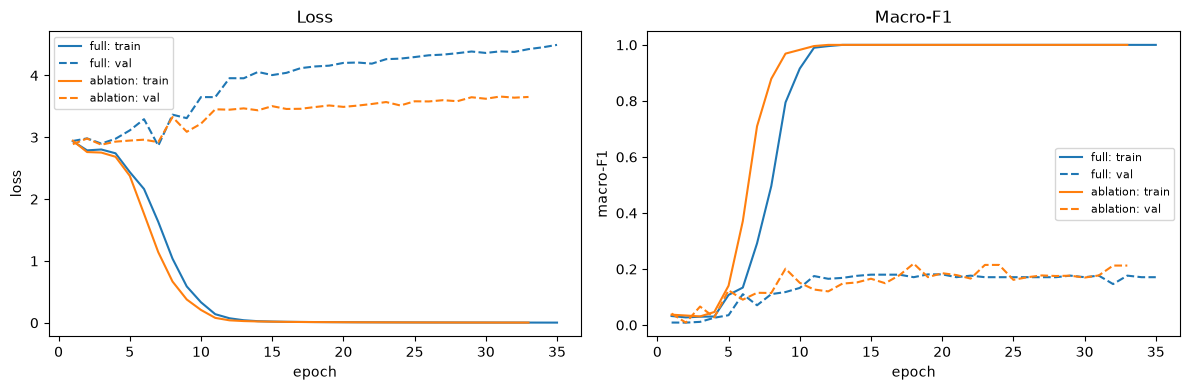

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_full = range(1, len(full_history["train_loss"]) + 1)
epochs_abl = range(1, len(ablation_history["train_loss"]) + 1)

axes[0].plot(epochs_full, full_history["train_loss"], color="tab:blue", label="full: train")
axes[0].plot(epochs_full, full_history["val_loss"], color="tab:blue", linestyle="--", label="full: val")
axes[0].plot(epochs_abl, ablation_history["train_loss"], color="tab:orange", label="ablation: train")
axes[0].plot(epochs_abl, ablation_history["val_loss"], color="tab:orange", linestyle="--", label="ablation: val")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].set_title("Loss"); axes[0].legend(fontsize=8)

axes[1].plot(epochs_full, full_history["train_f1"], color="tab:blue", label="full: train")
axes[1].plot(epochs_full, full_history["val_f1"], color="tab:blue", linestyle="--", label="full: val")
axes[1].plot(epochs_abl, ablation_history["train_f1"], color="tab:orange", label="ablation: train")
axes[1].plot(epochs_abl, ablation_history["val_f1"], color="tab:orange", linestyle="--", label="ablation: val")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1"); axes[1].set_title("Macro-F1"); axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()


**Reading the curves:** watch for the same overfitting signature M3's notebook called out --
train macro-F1 climbing to 1.000 while val loss stops following train loss down (or starts
rising again). With only 365 training rows and 40 validation rows, both models here have ample
capacity to memorize the training set; early stopping (restoring the best checkpoint by val
macro-F1, not the final epoch's weights) exists precisely to not hand back an overfit model.


## Step 6 - Evaluate both models on the held-out test episodes

Both models are evaluated on the exact same 107-row test split (2 held-out episodes), never
seen during training or for early stopping.


In [8]:
def evaluate(model, label):
    print("=" * 70)
    print(f"EVALUATE: {label}")
    print("=" * 70)
    text_t, audio_t, video_t, mask_t, labels_t = test_tensors
    model.eval()
    with torch.no_grad():
        logits = model(text_t, audio_t, video_t, padding_mask=mask_t)
    preds_id = logits.argmax(dim=1).tolist()
    preds = [id2label[p] for p in preds_id]
    truth = [id2label[l] for l in labels_t.tolist()]

    acc = accuracy_score(truth, preds)
    macro_f1 = f1_score(truth, preds, average="macro", zero_division=0)
    print(f"Accuracy : {acc:.3f}")
    print(f"Macro-F1 : {macro_f1:.3f}")
    return acc, macro_f1, truth, preds


full_acc, full_f1, truth, full_preds = evaluate(full_model, "full cross-modal model")
print()
ablation_acc, ablation_f1, _, ablation_preds = evaluate(ablation_model, "ablation (no cross-attention)")


EVALUATE: full cross-modal model
Accuracy : 0.299
Macro-F1 : 0.180

EVALUATE: ablation (no cross-attention)
Accuracy : 0.243
Macro-F1 : 0.157


In [9]:
print(classification_report(truth, full_preds, zero_division=0))


              precision    recall  f1-score   support

      Advise       0.10      0.25      0.14         4
       Agree       0.00      0.00      0.00         1
   Apologise       0.83      0.36      0.50        14
     Arrange       0.14      0.25      0.18         4
Ask for help       0.00      0.00      0.00         1
        Care       0.40      0.40      0.40         5
     Comfort       0.00      0.00      0.00         6
    Complain       0.20      0.33      0.25         6
   Criticize       0.36      0.50      0.42         8
      Flaunt       0.00      0.00      0.00         0
       Greet       0.50      0.25      0.33         4
      Inform       0.31      0.46      0.37        24
   Introduce       0.00      0.00      0.00         6
        Joke       0.00      0.00      0.00         2
       Leave       0.33      0.20      0.25         5
      Oppose       0.00      0.00      0.00         1
      Praise       0.17      0.12      0.14         8
     Prevent       0.00    

## Confusion matrix

For the full cross-modal model, on the same 20 real MIntRec intent classes used since M1.


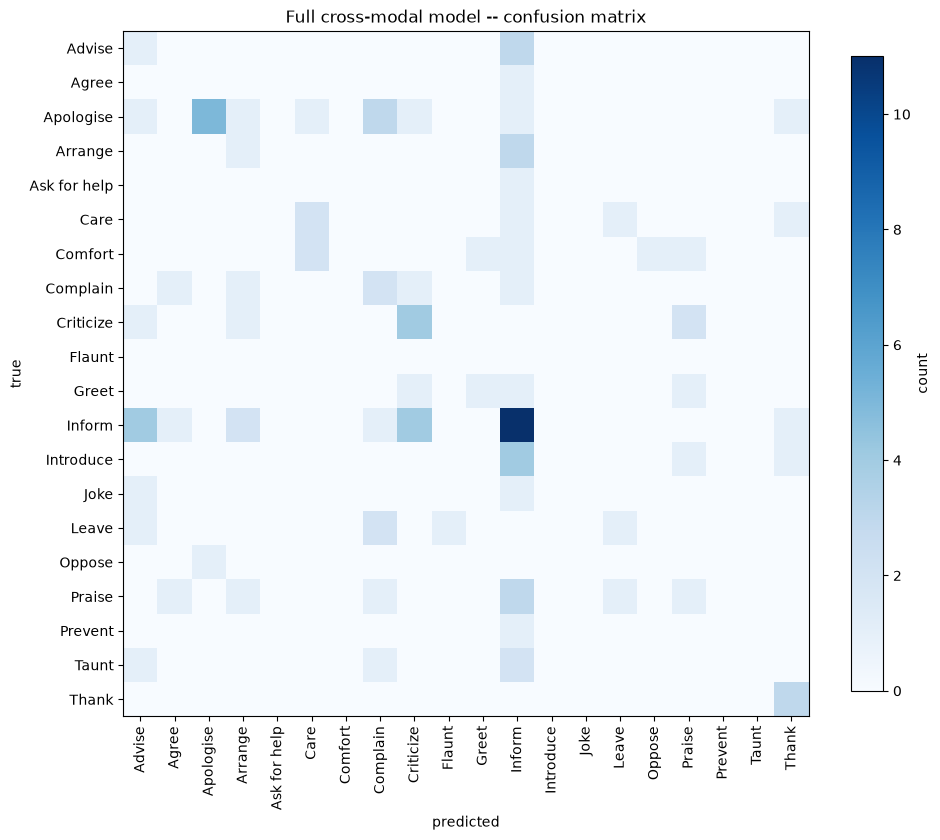

In [10]:
labels_present = sorted(set(truth) | set(full_preds))
cm = confusion_matrix(truth, full_preds, labels=labels_present)

fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_present)), labels_present, rotation=90)
ax.set_yticks(range(len(labels_present)), labels_present)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Full cross-modal model -- confusion matrix")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


## Compare against every prior milestone

Same honest caveat `src/train_crossmodal.py` prints at the end of its run: this milestone's
512-clip, 10-full-episode dataset is **different** from M2/M3's 300-clip stratified sample
(15 clips per class, scattered across 43 episodes) and different again from M1's full
2,224-row text-only dataset. These rows are directional comparisons across different data,
**not** a controlled like-for-like experiment -- the one apples-to-apples number in this
notebook is the full-vs-ablation comparison above, since those two models share the identical
data, split, and training procedure.


In [11]:
comparison = pd.DataFrame([
    {"model": "M1: text-only (real MIntRec, full 2,224-row dataset)", "accuracy": 0.508, "macro_f1": 0.409},
    {"model": "M2: concatenation fusion (300-clip stratified sample)", "accuracy": 0.117, "macro_f1": 0.096},
    {"model": "M3: MISA fusion (same 300-clip sample)", "accuracy": 0.333, "macro_f1": 0.295},
    {"model": "M4: full cross-modal + dialogue context (this run, 512-clip/10-episode data)", "accuracy": full_acc, "macro_f1": full_f1},
    {"model": "M4: ablation, no cross-attention (this run, same data/split)", "accuracy": ablation_acc, "macro_f1": ablation_f1},
]).set_index("model")
comparison


,accuracy,macro_f1
model,,
"M1: text-only (real MIntRec, full 2,224-row dataset)",0.508000,0.409000
M2: concatenation fusion (300-clip stratified sample),0.117000,0.096000
M3: MISA fusion (same 300-clip sample),0.333000,0.295000
"M4: full cross-modal + dialogue context (this run, 512-clip/10-episode data)",0.299065,0.179740
"M4: ablation, no cross-attention (this run, same data/split)",0.242991,0.157355


**Interpretation -- honest, not overclaimed.** On this run: full cross-modal model accuracy
0.299, macro-F1 0.180; ablation (identical architecture and data, cross-attention replaced with
mean-pooling) accuracy 0.243, macro-F1 0.157. The full model beats the ablation on both metrics
(+0.056 accuracy, +0.023 macro-F1) -- a genuine signal, on this data, that cross-attention
specifically contributes something beyond what the same-capacity ablation gets from
mean-pooling, since both models have identical capacity and were trained identically.

That is *not* the same as a settled conclusion. This is a **single seed** evaluated on a
**107-row test set** spread across 20 classes -- several classes have single-digit support, one
has support of exactly 1. Per M3's final review, which caught an earlier overclaimed causal
interpretation in this project by actually running a controlled ablation instead of trusting
the notebook's initial framing: a 0.056-point gap on one run, one seed, and this little test
data is a real and worth-reporting signal, but it is not proof that cross-attention will always
outperform mean-pooling here, or by how much, or that it would replicate on a different 2 held-
out episodes. Multi-seed, statistically-grounded ablations belong to Milestone 5.

Also worth noting honestly: **this milestone still trails M3's MISA result** (0.299 vs. 0.333
accuracy) and M1's text-only baseline (0.299 vs. 0.508) -- though again, different datasets,
so this is directional, not a controlled comparison. Possible reasons, not mutually exclusive:
harder task (predicting from dialogue context introduces more ways to be wrong than a
stratified, class-balanced sample), less training data per class (365 training rows here vs.
195 for M3, but spread unevenly across 20 classes based on what 7 real episodes happen to
contain, not a balanced 15-per-class draw), or simply that cross-modal dialogue modeling on
this little data is a genuinely harder problem than single-utterance classification on a
curated sample.


## Look at the mistakes


In [12]:
results_df = pd.DataFrame({"text": test["target_text"].tolist(), "true": truth, "predicted": full_preds})
mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"{len(mistakes)} of {len(results_df)} test utterances were misclassified ({len(mistakes)/len(results_df):.1%}).")
mistakes.head(10)


75 of 107 test utterances were misclassified (70.1%).


,text,true,predicted
0,your blouse is decent too,Praise,Inform
2,my advice--don't get lost in the siblings.,Advise,Inform
3,it's the parents you want to impress,Advise,Inform
4,it was just sitting on her shoulder like a par...,Introduce,Praise
5,too narrow.,Complain,Agree
6,"i'm sorry for the jargon, jonah.",Apologise,Thank
7,filled up on bread is gonna go on her gravest...,Joke,Inform
8,"glenn, this is dr. brian patterson, veterinari...",Introduce,Inform
9,nice to meet you.,Leave,Complain
10,"okay, dina, relax. it's just a surprise date.",Comfort,Praise


## Exercises

1. Try `CONTEXT_SIZE = 2` instead of `4` in `src/crossmodal_model.py` (this changes
   `WINDOW_SIZE` too, since `WINDOW_SIZE = CONTEXT_SIZE + 1`) and rerun `src/train_crossmodal.py`.
   Does less dialogue context help or hurt accuracy? A shorter window means less information but
   also less padding for episodes' early utterances -- which effect wins?
2. Open `data/dialogue/index.csv` and read a few rows' `context_sample_ids` chains alongside
   their `clip` numbers within one episode. The design spec for this milestone documents an
   **unverified assumption**: that ascending clip number approximates the episode's actual
   chronological order (the Hugging Face mirror only provides an integer clip number, not a
   timestamp). Judge for yourself whether the text reads like a coherent conversation in that
   order, or whether it looks shuffled.
3. `HIDDEN_DIM = 128` above, same as M3. Try a smaller value (e.g. 32) -- with only 365 training
   rows spread across 20 classes, does a smaller model overfit less and generalize better?


## Pitfalls and extensions

**Common mistake to avoid in your own future projects:** whenever a model's input includes
information *about other rows* (context, neighbors, history, graph edges -- not just this
milestone's dialogue window), a plain row-level `train_test_split` is not automatically safe.
It can silently leak information from train into test through those cross-row references, and
the resulting test accuracy will look better than the model actually deserves. The fix used
here -- split at the level of whatever *group* keeps related rows together (episodes, in this
case) -- generalizes: group-level splitting (e.g. `sklearn.model_selection.GroupShuffleSplit`)
is the standard tool for this, and it is worth checking for on every future dataset with any
row-to-row dependency, not just dialogue.

**Another pitfall this milestone worked to avoid:** crediting an accuracy number to the wrong
mechanism. M3's final review found that most of its headline improvement came from simply
having a trainable neural network at all, not specifically from MISA's shared/private
decomposition -- a controlled ablation wasn't run until the final review caught it. This
milestone ran its ablation (cross-attention vs. mean-pooling, same everything else) from the
start, not as an afterthought, and the "Compare against every prior milestone" section above
deliberately does not claim more than a single-seed, 107-row comparison can support.

**Extension:** a proper, statistically-grounded version of the full-vs-ablation comparison --
multiple seeds, confidence intervals or at least a spread like M3's exercises computed, and
ideally toggling one architectural change at a time -- belongs to **Milestone 5**
("evaluation, modality ablations, calibration, abstention"), which is exactly the milestone
this project's plan sets aside for that kind of rigor.
